# PROJET ML — CLASSIFICATION DE VIDÉOS YOUTUBE *TRENDING*

**Dataset Kaggle**: https://www.kaggle.com/datasets/datasnaek/youtube-new

**Objectif**: Développer un classificateur pour prédire si une vidéo YouTube deviendra *trending*.

> Ce notebook est conçu pour être complété. Chaque section contient des consignes détaillées et des zones de code à compléter.


## 1. Importation des librairies

**Consigne 1.1 — Importez toutes les librairies nécessaires**
- `pandas`, `numpy` pour la manipulation de données  
- `matplotlib.pyplot`, `seaborn` pour la visualisation  
- `sklearn` pour le machine learning  
- `warnings` pour supprimer les avertissements

In [1]:
# VOTRE CODE ICI - Section 1.1

# Pour la manipulation de données 
import pandas as pd
import numpy as np 

# Pour la visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

# Pour le machine learning
import sklearn

# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement et exploration des données

**Consigne 2.1 — Chargement des données**
- Chargez le fichier `USvideos.csv` avec pandas  
- Affichez les 5 premières lignes  
- Affichez les informations générales (`info()`, `shape`, `describe()`)

*Aide* :
- Utilisez `pd.read_csv()` avec `encoding='utf-8'`
- `.info()` donne les types de colonnes et valeurs non-nulles
- `.describe()` donne les statistiques descriptives

In [2]:
#VOTRE CODE ICI - Section 2.1
# Chargement et exportation des données 

df = pd.read_csv('data/USvideos.csv', encoding='utf-8')

# Affichage des 5 premiers lignes 
print(f"Premières lignes:{df.head(5)}")

# Les types de données 
print("\nInformations générales:", {df.info()})

# Obtenir le nombre de colonne dans le dataframe
print("Shape:", df.shape)

# Résumer statistique des colonnes dans le df
(df.describe(include='all').transpose())

Premières lignes:      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                                                ta

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,40949,6351,j4KvrAUjn6c,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,40949,205,17.14.11,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,40949,6455,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,40949,2207,ESPN,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,40949.0,NaN,NaN,NaN,19.972429,7.568327,1.0,17.0,24.0,25.0,43.0
publish_time,40949,6269,2018-05-18T14:00:04.000Z,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,40949,6055,[none],1535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,40949.0,NaN,NaN,NaN,2360784.638257,7394113.759704,549.0,242329.0,681861.0,1823157.0,225211923.0
likes,40949.0,NaN,NaN,NaN,74266.702435,228885.338209,0.0,5424.0,18091.0,55417.0,5613827.0
dislikes,40949.0,NaN,NaN,NaN,3711.400889,29029.705945,0.0,202.0,631.0,1938.0,1674420.0


**Consigne 2.2 — Analyse des valeurs manquantes**  
- Comptez les valeurs manquantes par colonne  
- Identifiez les colonnes avec le plus de valeurs manquantes  
- Affichez le pourcentage de valeurs manquantes

In [3]:
# VOTRE CODE ICI - Section 2.2

# Nombre de valeurs manquantes par colonne
missing = df.isnull().sum()

# Pourcentage de valeurs manquantes
pct_missing = (missing / len(df)) * 100

print("Valeurs manquantes (nombre):")
display(missing[missing > 0].sort_values(ascending=False))

print("\nValeurs manquantes (pourcentage):")
display(pct_missing[pct_missing > 0].sort_values(ascending=False))

Valeurs manquantes (nombre):


description    570
dtype: int64


Valeurs manquantes (pourcentage):


description    1.391975
dtype: float64

**Consigne 2.3 — Exploration des catégories**  
- Chargez le fichier JSON des catégories (`US_category_id.json`)  
- Fusionnez avec le DataFrame principal  
- Affichez la distribution des catégories

*Aide* : La structure JSON est du type:  
`{"items": [{"id": "1", "snippet": {"title": "Film & Animation"}}, ...]}`

In [4]:
# VOTRE CODE ICI - Section 2.3
import json
import pandas as pd
# Chargement du fichier JSON des catégories
categories_raw = pd.read_json('data/US_category_id.json')

# Conversion de la colonne items en liste
items = categories_raw['items'].tolist()

# Création d'un dictionnaire id_category:titre_category
category_dict = {int(item['id']): item['snippet']['title'] for item in items}

# Transformation de dataframe
cat_df = pd.DataFrame(list(category_dict.items()), columns=['category_id', 'category_title'])

# Jointure avec le dataframe principal
df_merged = df.merge(cat_df, how='left', left_on='category_id', right_on='category_id')

# Affichage et somme de nombre de vidéo
print("Distribution des catégories:")
display(df_merged['category_title'].value_counts().to_frame('count'))

Distribution des catégories:


,count
category_title,
Entertainment,9964
Music,6472
Howto & Style,4146
Comedy,3457
People & Blogs,3210
News & Politics,2487
Science & Technology,2401
Film & Animation,2345
Sports,2174


# Visualisation sur la distribution des catégories

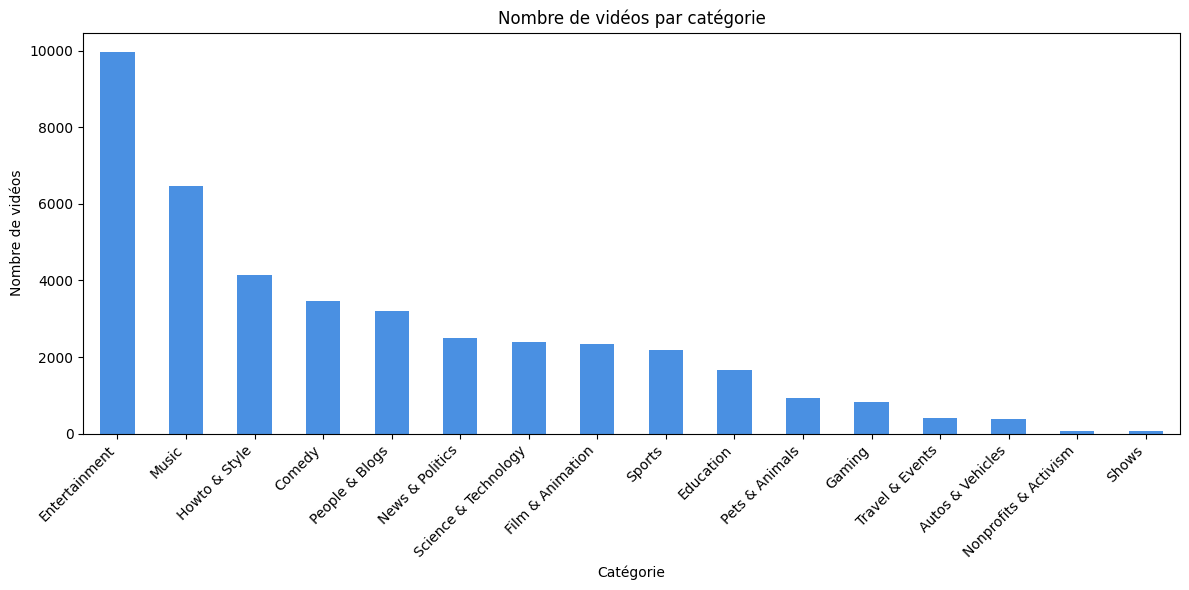

In [28]:
# Visualisation de la distribution des catégories
import matplotlib.pyplot as plt

category_counts = df_merged['category_title'].value_counts()

plt.figure(figsize=(12,6))
category_counts.plot(kind='bar', color='#4A90E2')
plt.title("Nombre de vidéos par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de vidéos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Nettoyage des données

**Consigne 3.1 — Nettoyage des données**
- Supprimez les doublons basés sur `video_id`  
- Gérez les valeurs manquantes dans `description` (remplacez par string vide)  
- Convertissez `publish_time` en datetime  
- Supprimez les lignes avec des valeurs aberrantes (ex: `views` négatives)

In [5]:
# VOTRE CODE ICI - Section 3.1

# Suppression des doublons 
df_clean = df.drop_duplicates(subset='video_id').copy()

# Remplacer les valeurs manquantes dans description par un string vide
df_clean['description'] = df_clean['description'].fillna('')

import pandas as pd
# Convertion de la colonne publish_time en datetime
df_clean['publish_time'] = pd.to_datetime(df_clean['publish_time'], errors='coerce')

# Détection des valeurs abérrantes
df_clean = df_clean[(df_clean['views'] >= 0) & (df_clean['likes'] >= 0) & (df_clean['dislikes'] >= 0) & (df_clean['comment_count'] >= 0)]

# Suppresion des lignes avec les valeurs aberrantes
df_clean = df_clean.dropna(subset=['publish_time'])

## 4. Feature Engineering

**Consigne 4.1 — Variables d'engagement**
** définition : https://support.google.com/youtube/answer/2991785?hl=fr**

In [6]:
# VOTRE CODE ICI - Section 4.1
import numpy as np
eps = 1e-9 # Pour éviter la division par 0

# Calcule du ratio Like des vidéo : likes ÷ (likes + dislikes)
denom = df_clean['likes'] + df_clean['dislikes'] # premier calcul

df_clean['like_ratio'] = np.where(denom > 0, df_clean['likes'] / denom, 0) # calcul de ratio

# Calcul du engagement rate : (likes + dislikes + commentaires) ÷ vues
df_clean['engagement_rate'] = np.where(df_clean['views'] > 0, # création d'une colonne pour l'engagement
(df_clean['likes'] + df_clean['dislikes'] + df_clean['comment_count']) / (df_clean['views'] + eps),
0) 

#  Calcul du comments per view : commentaires/ view                                 
df_clean['comments_per_view'] = np.where(df_clean['views'] > 0, df_clean['comment_count'] / (df_clean['views'] + eps), 0)

**Consigne 4.2 — Variables temporelles**

In [7]:
# VOTRE CODE ICI - Section 4.2
# calcule de la colonne publish hour 
df_clean['publish_hour'] = df_clean['publish_time'].dt.hour  # Dans le datetime récupére uniquement l'heure

# calcule de la colonne publish day_of_week
df_clean['publish_day_of_week'] = df_clean['publish_time'].dt.day_of_week # Dans le datetime récupére uniquement le jour

# calcule de la colonne publish_month
df_clean['publish_month'] = df_clean['publish_time'].dt.month # Dans le datetime récupére uniquement le mois

**Consigne 4.3 — Variables textuelles (titre)**

In [8]:
# VOTRE CODE ICI - Section 4.3

# Calcule de la longueur du titre
df_clean['title_length'] = df_clean['title'].str.len()

# # Compter le nombre de mot dans le titre
df_clean['title_word_count'] = df_clean['title'].str.split().apply(len)

# # Création de la colonne has_caps : 1 ou 0 si le titre contient au moin un mot en MAJUSCULE
df_clean['has_caps'] = df_clean['title'].str.split().apply(lambda words: any(word.isupper()for word in words)).astype(int)

# # Création de la colonne has_caps : 1 ou 0 si le titre contient au moin des nombres
df_clean['has_numbers'] = df_clean['title'].str.split().apply(lambda words: any(word.isdigit()for word in words)).astype(int)


## 5. Création de la variable cible

**Consigne 5.1 — Définition de `is_trending`**  
- Une vidéo est *trending* si elle a plus de vues que le 80e percentile de sa catégorie

In [9]:
# VOTRE CODE ICI - Section 5.1
df_clean['is_trending'] = (df_clean.groupby('category_id')['views']
                                   .transform(lambda x: x > x.quantile(0.8))).astype(int)
print("Distribution de la variable cible:")
display(df_clean['is_trending'].value_counts().to_frame('count'))

Distribution de la variable cible:


,count
is_trending,
0,5078
1,1273


# Visualisation sur la colération des variables 

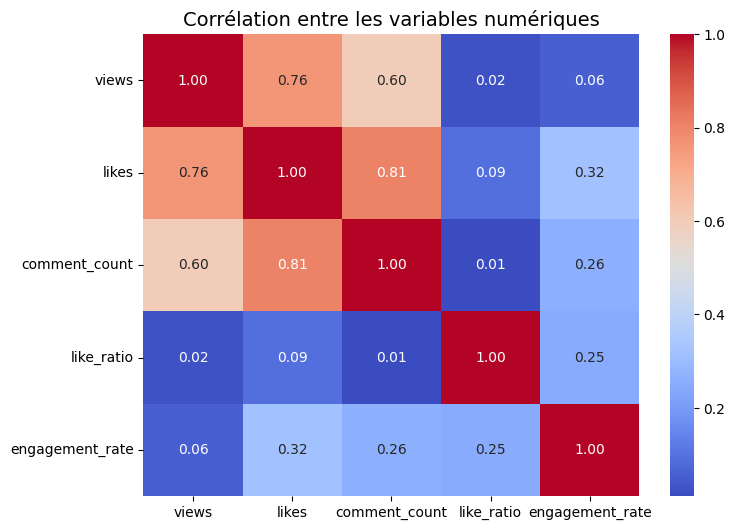

In [10]:
#Section 5.2 : Visualisation des données
import matplotlib.pyplot as plt
import seaborn as sns

# Calculer la matrice de corrélation
corr = df_clean[['views', 'likes', 'comment_count', 'like_ratio', 'engagement_rate']].corr()

# Visualisation
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre les variables numériques", fontsize=14)
plt.show()

## 6. Préparation des données pour l'entraînement

**Consignes 6.1 & 6.2 — Sélection des features & split train/test**

In [11]:
# VOTRE CODE ICI - Section 6.1 et 6.2

# Les features sur lesquelles il doit cet basé pour voir si il est trending 
features = ['views', 'likes', 'dislikes', 'comment_count',
             'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']
X = df_clean[features].copy()
y = df_clean['is_trending'].copy()

# Création des partie pour train et test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42, stratify=y
)
print(f"Taille train: {X_train.shape}")
print(f"Taille test: {X_test.shape}")

Taille train: (5080, 9)
Taille test: (1271, 9)


**Consigne 6.3 — Normalisation des données (StandardScaler)**

In [12]:
# VOTRE CODE ICI - Section 6.3
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   # Standarlisation des données
num_cols = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']
# # Fit uniquement sur train
scaler.fit(X_train[num_cols])

# Application de la normalisation sur les colonnes : Permet de ranger les données entre 0 et 1 pour éviter les erreurrs 
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#afficher les 5 premières lignes des données d'entraînement après la standardisation
print("Exemple des données après standardisation :") 
display(X_train.head())

#afficher les statistiques descriptives avant et après standardisation
print("Avant standardisation :")
display(df_clean[num_cols].describe().T)

print("Après standardisation (X_train) :")
display(X_train[num_cols].describe().T)

Exemple des données après standardisation :


,views,likes,dislikes,comment_count,like_ratio,engagement_rate,title_length,publish_hour,category_id
13469,-0.369787,-0.285285,-0.105433,-0.203456,0.225272,-0.421849,-0.144616,0.689587,-0.480376
37954,0.415471,0.915505,-0.039759,0.253239,0.522810,1.255022,0.261521,1.151799,0.769357
5049,-0.082469,0.193701,-0.058314,-0.044754,0.478858,1.369492,-1.819932,-1.775543,-1.452391
24555,-0.183343,-0.100835,-0.001648,-0.125133,0.088885,0.403236,0.109219,0.997729,0.769357
3254,-0.378833,-0.287772,-0.108897,-0.197793,0.447856,-0.140594,2.495275,-0.851119,-2.702124


Avant standardisation :


,count,mean,std,min,25%,50%,75%,max
views,6351.0,758209.564478,1.928993e+06,549.0,83511.000000,270902.000000,751266.500000,4.843165e+07
likes,6351.0,34493.569832,1.162439e+05,0.0,1908.000000,7987.000000,25163.000000,3.880071e+06
dislikes,6351.0,1427.222012,1.207881e+04,0.0,72.000000,242.000000,763.000000,6.291200e+05
comment_count,6351.0,4501.707290,2.146022e+04,0.0,261.000000,921.000000,2845.000000,7.333730e+05
like_ratio,6351.0,0.929590,1.235759e-01,0.0,0.932162,0.970833,0.985858,1.000000e+00
engagement_rate,6351.0,0.047648,3.898611e-02,0.0,0.019248,0.038028,0.064054,3.302553e-01
title_length,6351.0,49.774524,1.971143e+01,3.0,35.000000,48.000000,62.000000,1.000000e+02
publish_hour,6351.0,13.520863,6.493522e+00,0.0,9.000000,15.000000,18.000000,2.300000e+01
category_id,6351.0,20.444182,7.213046e+00,1.0,17.000000,24.000000,25.000000,4.300000e+01


Après standardisation (X_train) :


,count,mean,std,min,25%,50%,75%,max
views,5080.0,-2.797412e-18,1.000098,-0.394582,-0.350734,-0.253411,-0.003205,24.911413
likes,5080.0,-2.272898e-17,1.000098,-0.297695,-0.280965,-0.226956,-0.078798,33.564612
dislikes,5080.0,4.196119e-18,1.000098,-0.110283,-0.104605,-0.091420,-0.052886,48.326749
comment_count,5080.0,6.993531e-18,1.000098,-0.204323,-0.192324,-0.161645,-0.074394,33.288394
like_ratio,5080.0,9.287409e-16,1.000098,-7.715952,0.021202,0.335491,0.459286,0.577098
engagement_rate,5080.0,-6.154307e-17,1.000098,-1.225751,-0.725641,-0.242288,0.418500,7.247782
title_length,5080.0,1.349751e-16,1.000098,-2.378371,-0.753822,-0.093849,0.616891,2.546042
publish_hour,5080.0,1.468641e-16,1.000098,-2.083684,-0.697048,0.227376,0.689587,1.459941
category_id,5080.0,1.258836e-17,1.000098,-2.702124,-0.480376,0.491638,0.630498,3.129964


## 7. Modèle 1 — Random Forest

**Consigne 7.1 — Entraînement**

In [13]:
# VOTRE CODE ICI - Section 7.1
from sklearn.ensemble import RandomForestClassifier
# Création du modéle Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,  # Nombre d’arbres dans la forêt (par défaut = 100)
    random_state= 42, # pour avoir les mêmes résultats à chaque exécution
    n_jobs=1) # pour paralléliser le calcul et accélérer l’entraînement/ n_jobs=-1 utilise tous les cœurs disponibles
     
# Entrainement du modéle, (.fit = Application)
rf_model.fit(X_train, y_train)

# Prédiction sur le jeu test
rf_predictions = rf_model.predict(X_test[num_cols])

**Consigne 7.2 — Évaluation**

In [14]:
# VOTRE CODE ICI - Section 7.2

# Evaluation du modéles 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print("Random Forest - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
print(f"Recall: {recall_score(y_test, rf_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")

# # Importance des variables
import pandas as pd
feature_importance = pd.DataFrame({
     'feature': X.columns,
     'importance': rf_model.feature_importances_
 }).sort_values('importance', ascending=False)
print("\nTop 10 variables importantes:")
display(feature_importance.head(10))

Random Forest - Résultats:
Accuracy: 0.9717
Precision: 0.9582
Recall: 0.8980
F1-Score: 0.9271

Top 10 variables importantes:


,feature,importance
0,views,0.489141
2,dislikes,0.135988
1,likes,0.110925
3,comment_count,0.080337
8,category_id,0.080145
5,engagement_rate,0.051447
4,like_ratio,0.021603
7,publish_hour,0.015366
6,title_length,0.015047


# Visualisation de l'importance des variables

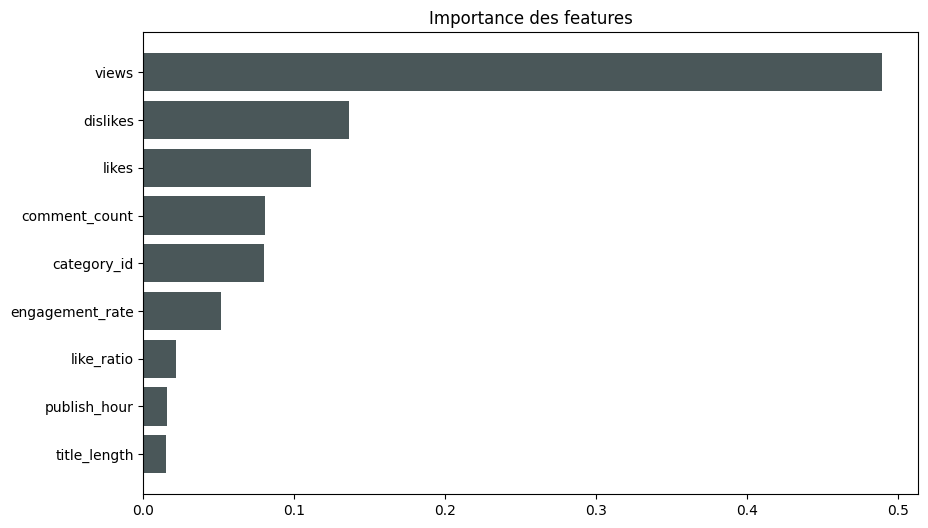

In [15]:
importances = rf_model.feature_importances_  # importance des variables
features = X_train.columns

df_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(df_importances['Feature'], df_importances['Importance'], color='#4A5759')
plt.gca().invert_yaxis()
plt.title("Importance des features")
plt.show()

## 8. Modèle 2 — Support Vector Machine (SVM)

**Consigne 8.1 — Entraînement (utiliser données normalisées)**

In [16]:
# VOTRE CODE ICI - Section 8.1
from sklearn.svm import SVC
# Création du modéle SVM avec le noyau RBF
# rbf permet de séparer les données pour éviter les problémes linéaire / C=1.0 pour etre correcte et général
svm_model = SVC(kernel='linear', C= 1, random_state=42)

# Entrainement du modéle sur les données normalisées
svm_model.fit(X_train[num_cols], y_train)

# Prédiction sur le jeu detest normalisé
svm_predictions = svm_model.predict(X_test[num_cols])

**Consigne 8.2 — Évaluation**

In [17]:
# VOTRE CODE ICI - Section 8.2
print("SVM - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
print(f"Precision: {precision_score(y_test, svm_predictions):.4f}")
print(f"Recall: {recall_score(y_test, svm_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, svm_predictions):.4f}")


SVM - Résultats:
Accuracy: 0.9426
Precision: 0.9136
Recall: 0.7882
F1-Score: 0.8463


## 9. Modèle 3 — Gradient Boosting (XGBoost)

**Consigne 9.1 — Entraînement**

In [18]:
# VOTRE CODE ICI - Section 9.1
try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0, random_state=42, n_jobs=-1, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)
except ImportError:
    print("XGBoost n'est pas installé. Installez avec: pip install xgboost")
    xgb_model = None
    xgb_predictions = None

**Consigne 9.2 — Évaluation**

In [19]:
#VOTRE CODE ICI - Section 9.2
if xgb_predictions is not None:
    print("XGBoost - Résultats:")
    print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
    print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")
    print(f"Recall: {recall_score(y_test, xgb_predictions):.4f}")
    print(f"F1-Score: {f1_score(y_test, xgb_predictions):.4f}")

XGBoost - Résultats:
Accuracy: 0.9929
Precision: 1.0000
Recall: 0.9647
F1-Score: 0.9820


## 10. Modèle 4 — Réseau de Neurones (MLPClassifier)

**Consigne 10.1 — Entraînement (données normalisées)**

In [20]:
# VOTRE CODE ICI - Section 10.1
from sklearn.neural_network import MLPClassifier
X_train_scaled = X_train[num_cols] # Les fonctions sur la normalisation
X_test_scaled = X_test[num_cols]

nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)
nn_model.fit(X_train_scaled, y_train)
nn_predictions = nn_model.predict(X_test_scaled)

**Consigne 10.2 — Évaluation**

In [21]:
# VOTRE CODE ICI - Section 10.2
print("Réseau de Neurones - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, nn_predictions):.4f}")
print(f"Precision: {precision_score(y_test, nn_predictions):.4f}")
print(f"Recall: {recall_score(y_test, nn_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, nn_predictions):.4f}")

# Nombre d'itérations
print(f"Nombre d'itérations: {nn_model.n_iter_}")

Réseau de Neurones - Résultats:
Accuracy: 0.9575
Precision: 0.8821
Recall: 0.9098
F1-Score: 0.8958
Nombre d'itérations: 265


## 11. Comparaison des modèles

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.971676,0.958159,0.898039,0.927126
1,SVM,0.942565,0.913636,0.788235,0.846316
2,XGBoost,0.992919,1.000000,0.964706,0.982036
3,Neural Network,0.957514,0.882129,0.909804,0.895753


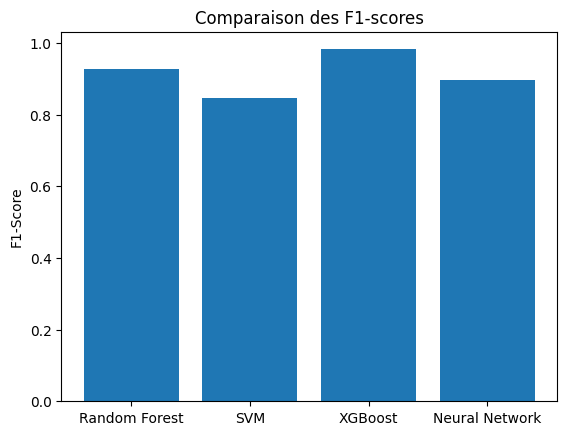

In [22]:
# VOTRE CODE ICI - Section 11.1
import pandas as pd
results = []
# Remplir en fonction des métriques calculées plus haut
results.append({'Model': 'Random Forest', 'Accuracy': accuracy_score(y_test, rf_predictions), 'Precision': precision_score(y_test,rf_predictions), 'Recall':recall_score(y_test,rf_predictions) , 'F1-Score': f1_score(y_test,rf_predictions)})
results.append({'Model': 'SVM', 'Accuracy': accuracy_score(y_test, svm_predictions), 'Precision': precision_score(y_test, svm_predictions), 'Recall': recall_score(y_test, svm_predictions), 'F1-Score': f1_score(y_test, svm_predictions)})
if xgb_predictions is not None: results.append({'Model': 'XGBoost', 'Accuracy': accuracy_score(y_test, xgb_predictions), 'Precision': precision_score(y_test, xgb_predictions), 'Recall': recall_score(y_test, xgb_predictions), 'F1-Score': f1_score(y_test, xgb_predictions)})
results.append({'Model': 'Neural Network', 'Accuracy': accuracy_score(y_test, nn_predictions), 'Precision': precision_score(y_test, nn_predictions), 'Recall': recall_score(y_test, nn_predictions), 'F1-Score': f1_score(y_test, nn_predictions)})
results_df = pd.DataFrame(results)
display(results_df)

# Graphique comparatif des F1-scores ( Plus le F1_score est proche de 1, la prédiction tant vers la vérité)
import matplotlib.pyplot as plt
plt.figure()
plt.bar(results_df['Model'], results_df['F1-Score'])
plt.title('Comparaison des F1-scores')
plt.ylabel('F1-Score')
plt.show()

## 12. Validation croisée

In [23]:
# VOTRE CODE ICI - Section 12.1
from sklearn.model_selection import cross_val_score
#Exemple avec le meilleur score : Gradient Boosting (XGBoost) 
scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f"Validation croisée - F1-Score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Validation croisée - F1-Score: 0.9827 (+/- 0.0089)


## 13. Optimisation des hyperparamètres (Grid Search)

In [24]:
# VOTRE CODE ICI - Section 13.1
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score CV:", grid_search.best_score_)
best_xgb = grid_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

Meilleurs paramètres: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Meilleur score CV: 0.9729272659974265


## 14. Analyse des erreurs

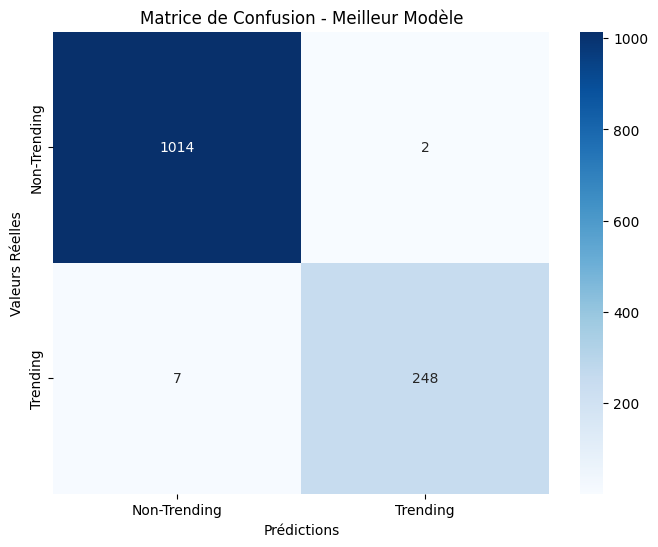

In [25]:
# VOTRE CODE ICI - Section 14.1
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Exemple: matrice de confusion pour le meilleur modèle 
cm = confusion_matrix(y_test, best_xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Trending', 'Trending'],
            yticklabels=['Non-Trending', 'Trending'])
plt.title('Matrice de Confusion - Meilleur Modèle')
plt.ylabel('Valeurs Réelles')
plt.xlabel('Prédictions')
plt.show()

In [26]:
# VOTRE CODE ICI - Section 14.2
# Identifier des exemples mal classifiés (adapter selon le modèle choisi)
errors_mask = (y_test != best_xgb_pred)
error_indices = X_test[errors_mask].index
print("Exemples de vidéos mal classifiées:")
for idx in list(error_indices)[:5]:
    real_label = y_test.loc[idx]
    predicted_label = best_xgb_pred[list(error_indices).index(idx)]  
    print(f"Index {idx}: Réel={real_label}, Prédit={predicted_label}")

Exemples de vidéos mal classifiées:
Index 38557: Réel=1, Prédit=0
Index 14601: Réel=1, Prédit=0
Index 40751: Réel=0, Prédit=0
Index 31753: Réel=1, Prédit=1
Index 10209: Réel=1, Prédit=0


## 15. Sauvegarde & conclusions

In [29]:
# VOTRE CODE ICI - Section 15.1
import joblib
# Remplacez 'best_rf' / 'scaler' par vos objets
joblib.dump(best_xgb, 'best_youtube_classifier.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print("Modèle et scaler sauvegardés avec succès!")

Modèle et scaler sauvegardés avec succès!
